# River Water Level Forecasting - Regression Analysis (Task 1)

**Practical Assignment: Regression Analysis**

**Name:** Ekanayake D.B  
**Index No:** 235514B

**Dataset:** Islandwide Water Level and Rainfall Situation in Major Rivers of Sri Lanka

---

## Objective

Develop a regression model capable of predicting the river water level **12 hours ahead**
(`Water_Level_Xt`) from the current river water level and the previous 24 hours of rainfall.

## Variables

| Variable | Description | Role |
|---|---|---|
| `Gauging_station` | Identifier of the gauging station | Identifier only |
| `Water_Level_Xt_1` | River water level (mm) at time t | Predictor (X1) |
| `24HrRF_Xt_1` | Total rainfall (mm) in the previous 24 hours at time t | Predictor (X2) |
| `Water_Level_Xt` | River water level (mm) at time t + 12 hours | Target (Y) |

## Contents

1. Setup and data loading  
2. Exploratory data analysis  
3. Data preprocessing  
4. Model development - univariate regression  
5. Model development - multivariate regression  
6. Model diagnostics  
7. Model evaluation  
8. Practical usefulness of the model  
9. Strengths and limitations  


## 1. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

df = pd.read_csv("training_data.csv")
print("Dataset shape:", df.shape)
df.head(10)

Dataset shape: (78, 4)


,Gauging_station,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
0,1,2.9000,NaN,1.5000
1,2,5.0000,23.2000,3.7100
2,3,12.6800,44.3000,11.0500
3,4,1.6000,51.7000,1.8100
4,5,1.2800,81.2000,0.8700
5,6,1.3100,78.7000,1.1000
6,7,0.6300,18.6000,0.6100
7,8,2.3000,12.1000,2.3600
8,9,8.1000,72.3000,7.9200
9,10,3.5600,46.3000,2.4100


The raw dataset is loaded. It contains 78 rows and 4 columns. Each row represents one observation
from a gauging station. The three measurement columns are numeric float values; `Gauging_station` is an
integer identifier that will not be used as a predictor.

## 2. Exploratory data analysis

### 2.1 Data types and basic structure

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gauging_station   78 non-null     int64  
 1   Water_Level_Xt_1  78 non-null     float64
 2   24HrRF_Xt_1       76 non-null     float64
 3   Water_Level_Xt    72 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 2.6 KB


### 2.2 Descriptive statistics

In [3]:
df[["Water_Level_Xt_1", "24HrRF_Xt_1", "Water_Level_Xt"]].describe()

,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
count,78.0000,76.0000,72.0000
mean,2.1333,21.4408,2.1449
std,2.5934,21.4245,2.3772
min,-3.2700,0.0000,-0.1300
25%,0.6300,3.3250,0.6175
50%,1.3250,14.9500,1.3550
75%,2.9525,32.3000,2.6525
max,12.6800,81.2000,11.7300


Several features emerge from the descriptive statistics:

- The current water level (`Water_Level_Xt_1`) and the target (`Water_Level_Xt`) have very similar
  means (about 2.1 mm), standard deviations, and quartiles. This reflects the physical reality that the
  river level changes gradually over a 12 hour window, so the current level is a strong baseline for
  what the level will be 12 hours later.
- Rainfall (`24HrRF_Xt_1`) ranges from 0 mm (dry catchments) up to 81.2 mm (heavy event). The mean
  (21.4 mm) exceeds the median, indicating a right skewed distribution.
- Both water level columns show minimum values below zero. These are physically valid readings recorded
  relative to a station-specific reference datum; a negative reading simply means the water surface
  is below that datum and is not an error.
- The count for `24HrRF_Xt_1` (76) and `Water_Level_Xt` (72) is below 78, confirming missing values
  that are addressed in preprocessing.

### 2.3 Missing value analysis

In [4]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
miss_table = pd.DataFrame({"Missing count": missing, "Missing (%)": missing_pct})
print(miss_table)
print()
print("Stations missing 24HrRF_Xt_1:",
      df.loc[df["24HrRF_Xt_1"].isna(), "Gauging_station"].tolist())
print("Stations missing Water_Level_Xt:",
      df.loc[df["Water_Level_Xt"].isna(), "Gauging_station"].tolist())
print()
print("Fully complete rows:", df.dropna().shape[0])

                  Missing count  Missing (%)
Gauging_station               0       0.0000
Water_Level_Xt_1              0       0.0000
24HrRF_Xt_1                   2       2.5600
Water_Level_Xt                6       7.6900

Stations missing 24HrRF_Xt_1: [1, 40]
Stations missing Water_Level_Xt: [28, 34, 35, 67, 73, 74]

Fully complete rows: 70


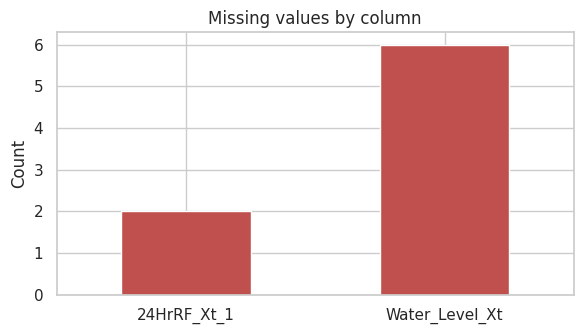

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
missing[missing > 0].plot(kind="bar", color="#c0504d", ax=ax)
ax.set_title("Missing values by column")
ax.set_ylabel("Count")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

There are two distinct missing data situations:

- `24HrRF_Xt_1` is missing for stations 1 and 40. These rows have valid current water levels and valid
  targets, so they can be recovered by imputation.
- `Water_Level_Xt` (the target) is missing for stations 28, 34, 35, 67, 73, and 74. A supervised
  regression model cannot be trained on rows that have no target value, and imputing a target would
  fabricate the very quantity the model is trying to learn. These 6 rows must be excluded from training.

The two groups do not overlap, leaving 78 - 6 = 72 usable training rows after the missing-target rows are
removed.

### 2.4 Distribution of variables

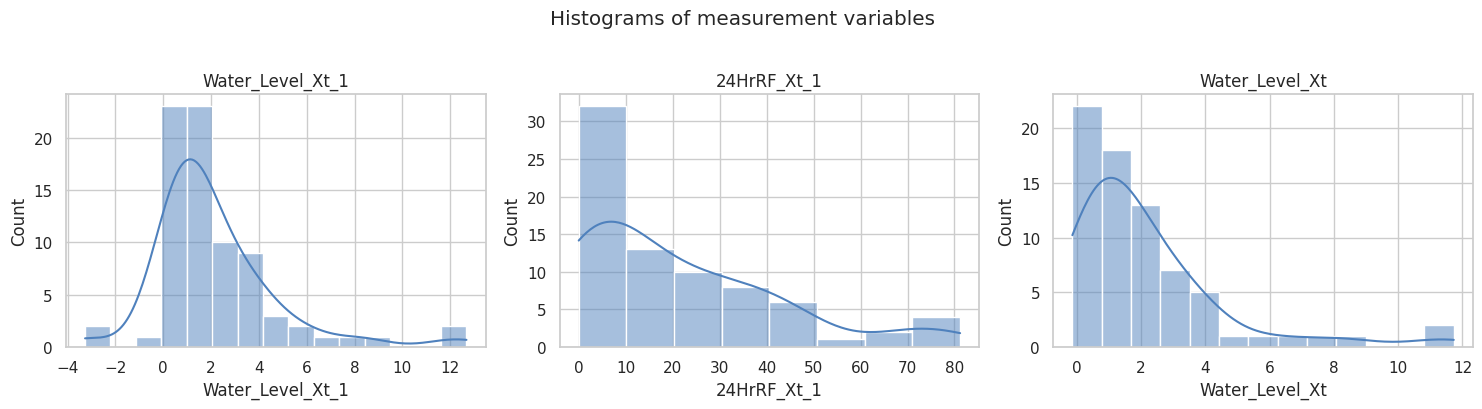

Skewness:
Water_Level_Xt_1   1.8080
24HrRF_Xt_1        1.1330
Water_Level_Xt     2.2560


In [6]:
num_cols = ["Water_Level_Xt_1", "24HrRF_Xt_1", "Water_Level_Xt"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4f81bd")
    ax.set_title(col)
plt.suptitle("Histograms of measurement variables", y=1.02)
plt.tight_layout()
plt.show()

print("Skewness:")
print(df[num_cols].skew().round(3).to_string())

All three variables are right skewed (positive skewness values of approximately 2.2, 1.1, and 2.2
respectively). The distributions have long upper tails driven by a small number of high flow stations and
heavy rain events. The bulk of observations sit at low water levels and low or zero rainfall. This skew
is noted because it may appear in the residuals; the diagnostic section will check this explicitly.

### 2.5 Boxplots and outlier inspection

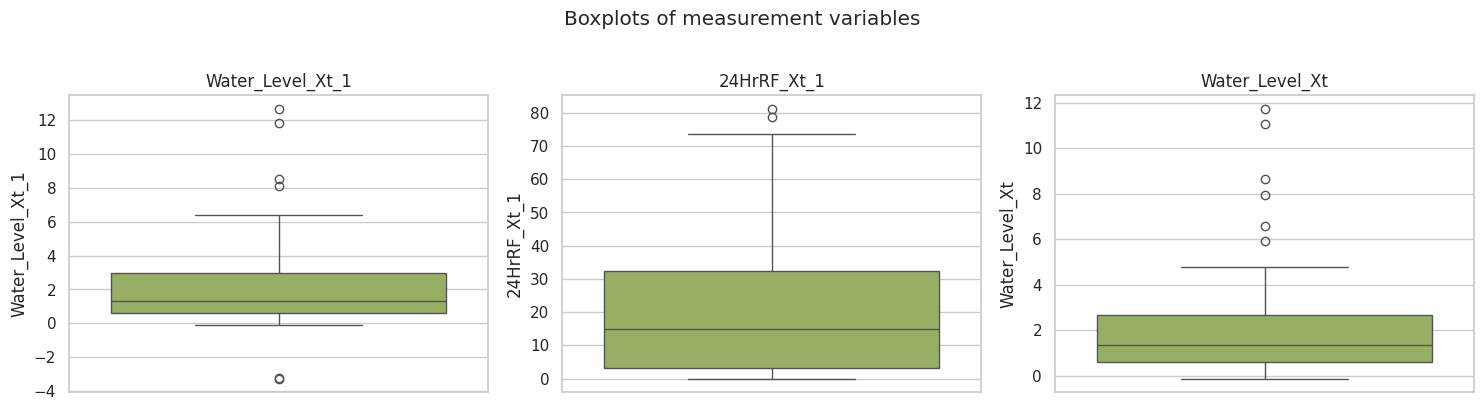

IQR-based outlier check (1.5 x IQR rule):
  Water_Level_Xt_1: fence [-2.85, 6.44], flagged stations = [3, 9, 28, 42, 48, 67]
  24HrRF_Xt_1: fence [-40.14, 75.76], flagged stations = [5, 6]
  Water_Level_Xt: fence [-2.44, 5.71], flagged stations = [3, 9, 12, 42, 48, 51]


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="#9bbb59")
    ax.set_title(col)
plt.suptitle("Boxplots of measurement variables", y=1.02)
plt.tight_layout()
plt.show()

print("IQR-based outlier check (1.5 x IQR rule):")
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = df.loc[(df[col] < lo) | (df[col] > hi), "Gauging_station"].tolist()
    print(f"  {col}: fence [{lo:.2f}, {hi:.2f}], flagged stations = {flagged}")

The IQR rule flags several stations at the upper end of the water level columns (for example,
stations 3, 9, 42, and 48). These correspond to genuinely large rivers carrying high flow and are real
measurements, not errors. Removing them would discard exactly the high water level behaviour the model
needs to capture. They are therefore retained throughout the analysis.

The negative water levels seen at the lower fence are valid as explained earlier. Two of these
(stations 28 and 67) are among the rows whose target is missing, so they are removed during preprocessing
for that separate reason.

### 2.6 Correlation analysis

Correlation Matrix:
                  Water_Level_Xt_1  24HrRF_Xt_1  Water_Level_Xt
Water_Level_Xt_1            1.0000       0.3634          0.9899
24HrRF_Xt_1                 0.3634       1.0000          0.3161
Water_Level_Xt              0.9899       0.3161          1.0000


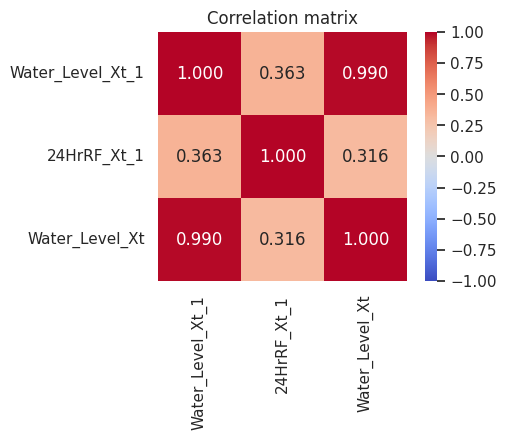

In [8]:
corr = df[num_cols].corr()
print("Correlation Matrix:")
print(corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

The correlation matrix reveals the central finding of the exploratory analysis:

- `Water_Level_Xt_1` and the target `Water_Level_Xt` have a correlation of approximately **0.99**. The
  current water level is an extremely strong linear predictor of the level 12 hours ahead.
- `24HrRF_Xt_1` has a much weaker correlation with the target (approximately **0.32**). Rainfall carries
  some predictive information, but far less than the current level alone.
- The two predictors are only moderately correlated with each other (approximately **0.36**), which means
  multicollinearity is not expected to be a serious concern when both are used together.

### 2.7 Scatter plots of predictor-target relationships

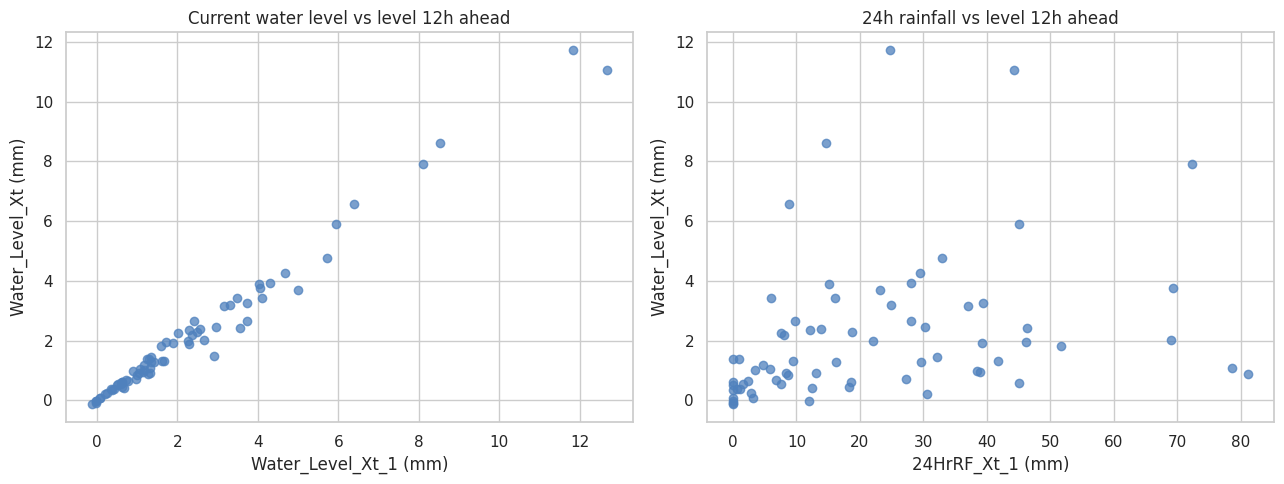

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["Water_Level_Xt_1"], df["Water_Level_Xt"],
                color="#4f81bd", alpha=0.75)
axes[0].set_xlabel("Water_Level_Xt_1 (mm)")
axes[0].set_ylabel("Water_Level_Xt (mm)")
axes[0].set_title("Current water level vs level 12h ahead")

axes[1].scatter(df["24HrRF_Xt_1"], df["Water_Level_Xt"],
                color="#4f81bd", alpha=0.75)
axes[1].set_xlabel("24HrRF_Xt_1 (mm)")
axes[1].set_ylabel("Water_Level_Xt (mm)")
axes[1].set_title("24h rainfall vs level 12h ahead")

plt.tight_layout()
plt.show()

The left scatter plot shows a tight, near-linear relationship between the current water level and
the target, consistent with the 0.99 correlation. The right scatter shows only a diffuse cloud for
rainfall, with no clear strong trend. These patterns confirm that a linear regression approach is
appropriate, and that the current water level will dominate the model.

### 2.8 Pairwise relationships

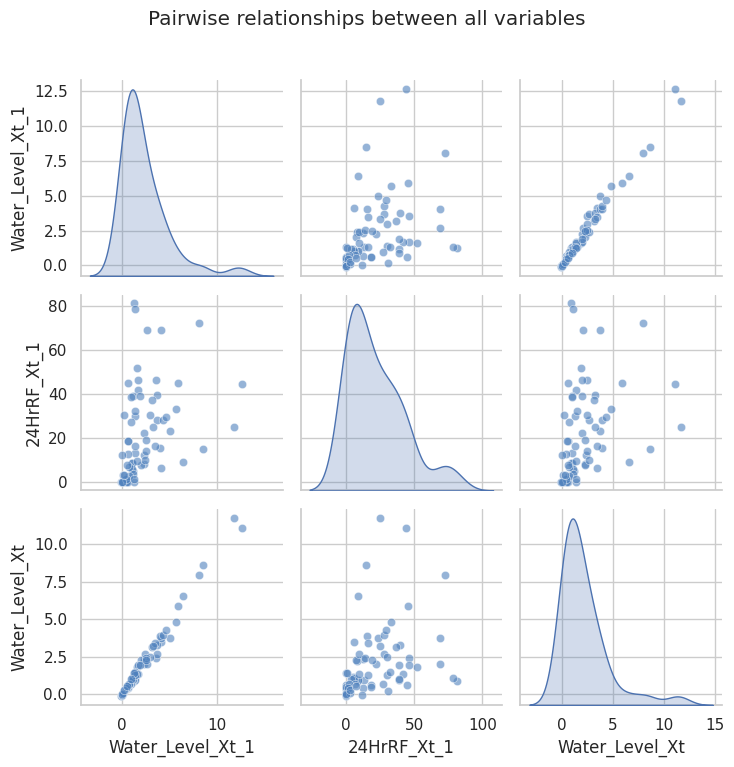

In [10]:
sns.pairplot(df[num_cols].dropna(), diag_kind="kde",
             plot_kws={"alpha": 0.6, "color": "#4f81bd"})
plt.suptitle("Pairwise relationships between all variables", y=1.02)
plt.tight_layout()
plt.show()

## 3. Data preprocessing

Based on the exploratory analysis, the preprocessing steps are minimal and targeted:

1. Remove `Gauging_station` from the modelling variables (identifier, not a predictor).
2. Remove rows with a missing target (cannot be used for supervised training).
3. Impute the 2 missing rainfall values with the median.
4. Retain all valid outliers and negative readings.

In [11]:
# Step 1: Separate the identifier
station_id = df["Gauging_station"].copy()
data = df.drop(columns=["Gauging_station"]).copy()

# Step 2: Remove rows with missing target
before = len(data)
data = data.dropna(subset=["Water_Level_Xt"]).copy()
print(f"Removed {before - len(data)} rows with missing target.")
print(f"Remaining rows: {len(data)}")

# Step 3: Impute missing rainfall with the median
rain_median = data["24HrRF_Xt_1"].median()
print(f"\nMedian rainfall used for imputation: {rain_median:.2f} mm")
data["24HrRF_Xt_1"] = data["24HrRF_Xt_1"].fillna(rain_median)

# Verify
print(f"\nMissing values remaining: {data.isna().sum().sum()}")
print(f"Final modelling dataset shape: {data.shape}")

Removed 6 rows with missing target.
Remaining rows: 72

Median rainfall used for imputation: 15.65 mm

Missing values remaining: 0
Final modelling dataset shape: (72, 3)


`Gauging_station` is an arbitrary label; using it as a numeric predictor would introduce a
meaningless ordering into the model. It is therefore kept only for reference and removed from the
modelling frame.

The 6 rows without a target cannot contribute to parameter estimation and are excluded. The 2 missing
rainfall values are imputed with the median rather than the mean because rainfall is right skewed; the
median is a more representative central value that is not pulled toward the heavy rain tail. With only 2
imputed points the effect on the analysis is negligible, while these rows' valid current level and target
information is preserved.

All flagged outliers and negative water level readings are retained because they represent real
physical conditions the model must learn.

In [12]:
print("Clean dataset summary statistics:")
data.describe()

Clean dataset summary statistics:


,Water_Level_Xt_1,24HrRF_Xt_1,Water_Level_Xt
count,72.0000,72.0000,72.0000
mean,2.3454,21.7708,2.1449
std,2.5184,20.5432,2.3772
min,-0.1200,0.0000,-0.1300
25%,0.6600,5.9500,0.6175
50%,1.3750,15.6500,1.3550
75%,3.2025,32.3000,2.6525
max,12.6800,81.2000,11.7300


## 4. Model development - Univariate (simple linear) regression

### 4.1 Model specification

The univariate model uses only the current water level as the predictor:

$$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X_1$$

where $Y$ is `Water_Level_Xt` (level 12 hours ahead) and $X_1$ is `Water_Level_Xt_1`
(current water level). Parameters are estimated by ordinary least squares (OLS), which minimises the
sum of squared residuals.

In [13]:
y = data["Water_Level_Xt"]

# Define predictor and add the constant (intercept) term
X_uni = sm.add_constant(data[["Water_Level_Xt_1"]])

# Fit the OLS model
model_uni = sm.OLS(y, X_uni).fit()

print(model_uni.summary())

                            OLS Regression Results                            
Dep. Variable:         Water_Level_Xt   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     3410.
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           4.02e-61
Time:                        16:07:58   Log-Likelihood:                -23.377
No. Observations:                  72   AIC:                             50.75
Df Residuals:                      70   BIC:                             55.31
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0467      0.055  

### 4.2 Interpretation of the univariate model

**Fitted equation:**

$$\hat{Y} = -0.0467 + 0.9344 \cdot X_1$$

- **Intercept (-0.0467):** The predicted water level 12 hours ahead when the current level is 0 mm.
  In practice this has no direct physical meaning because a reading of exactly 0 is a datum crossing
  rather than a meaningful condition. The intercept is not statistically significant (p = 0.398),
  which is consistent with this interpretation.
- **Slope (0.9344):** For every 1 mm increase in the current water level, the predicted level 12 hours
  later increases by approximately 0.93 mm, holding all else constant. The slope is very close to 1,
  meaning the river level is nearly persistent over a 12 hour period. This coefficient is highly
  statistically significant (p < 0.0001).

**Overall model fit:**

- R-squared = 0.980: the current water level alone explains approximately **98.0%** of the variation
  in the level 12 hours ahead. This is an exceptionally high fit.
- The F-statistic (3410, p < 0.0001) confirms that the model as a whole is statistically significant.

### 4.3 Fitted line plot

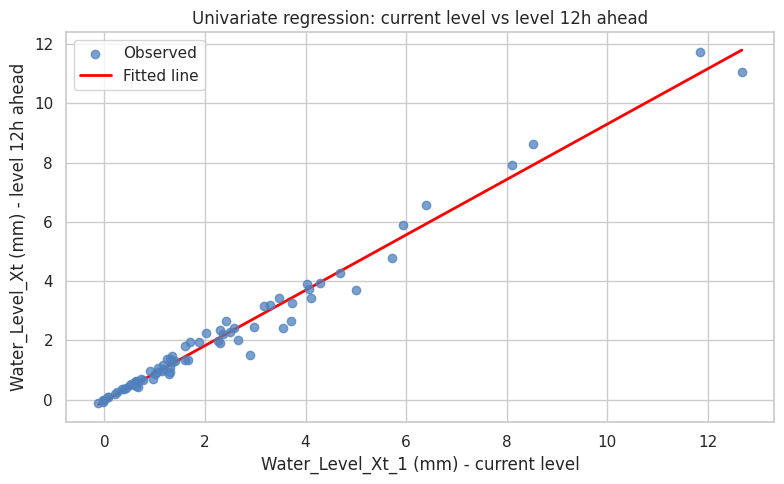

In [14]:
x_range = np.linspace(data["Water_Level_Xt_1"].min(),
                      data["Water_Level_Xt_1"].max(), 200)
y_fitted = model_uni.params["const"] + model_uni.params["Water_Level_Xt_1"] * x_range

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(data["Water_Level_Xt_1"], y, color="#4f81bd",
           alpha=0.75, label="Observed", zorder=3)
ax.plot(x_range, y_fitted, color="red", linewidth=2, label="Fitted line")
ax.set_xlabel("Water_Level_Xt_1 (mm) - current level")
ax.set_ylabel("Water_Level_Xt (mm) - level 12h ahead")
ax.set_title("Univariate regression: current level vs level 12h ahead")
ax.legend()
plt.tight_layout()
plt.show()

The fitted line passes closely through the observed data cloud, visually confirming the very high
R-squared. The relationship is clearly linear across the full range of water levels.

## 5. Model development - Multivariate (multiple linear) regression

### 5.1 Model specification

The multivariate model adds the 24-hour rainfall as a second predictor:

$$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \hat{\beta}_2 X_2$$

where $X_1$ is `Water_Level_Xt_1` and $X_2$ is `24HrRF_Xt_1`. Both parameters are estimated
simultaneously by OLS.

In [15]:
X_mul = sm.add_constant(data[["Water_Level_Xt_1", "24HrRF_Xt_1"]])

model_mul = sm.OLS(y, X_mul).fit()

print(model_mul.summary())

                            OLS Regression Results                            
Dep. Variable:         Water_Level_Xt   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.980
Method:                 Least Squares   F-statistic:                     1725.
Date:                Thu, 25 Jun 2026   Prob (F-statistic):           1.23e-59
Time:                        16:07:59   Log-Likelihood:                -22.463
No. Observations:                  72   AIC:                             50.93
Df Residuals:                      69   BIC:                             57.76
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0046      0.063  

### 5.2 Interpretation of the multivariate model

**Fitted equation:**

$$\hat{Y} = -0.0046 + 0.9421 \cdot X_1 + (-0.0028) \cdot X_2$$

- **Intercept (-0.0046):** The predicted level 12 hours ahead when both predictors are zero. Not
  statistically significant (p = 0.943), consistent with the univariate model.
- **Coefficient of X1 (0.9421):** Holding rainfall constant, a 1 mm increase in the current water
  level leads to a predicted increase of approximately **0.94 mm** in the level 12 hours ahead.
  This is highly significant (p < 0.0001).
- **Coefficient of X2 (-0.0028):** Holding the current level constant, a 1 mm increase in 24-hour
  rainfall leads to a predicted decrease of approximately **0.003 mm** in the level 12 hours ahead.
  This coefficient is **not statistically significant** (p = 0.187). The negative sign is
  counterintuitive (more rain slightly lowering the predicted level), and its insignificance confirms
  that once the current level is accounted for, the additional information in rainfall does not
  meaningfully improve prediction.

**Overall model fit:**

- R-squared = 0.980 and adjusted R-squared = 0.980, essentially identical to the univariate model.
- The F-statistic (1725, p < 0.0001) confirms overall model significance.

**Comparison of the two models:**

| Metric | Univariate | Multivariate |
|---|---|---|
| R-squared | 0.980 | 0.980 |
| Adjusted R-squared | 0.980 | 0.980 |
| AIC | 50.75 | 50.93 |
| BIC | 55.31 | 57.76 |
| Rainfall p-value | - | 0.187 (not significant) |

The multivariate model offers no meaningful improvement in fit. Adjusted R-squared does not increase,
and AIC and BIC both rise when rainfall is added, penalising model complexity. The univariate model
is therefore preferred on grounds of parsimony.

## 6. Model diagnostics

Regression diagnostics are conducted for both models. Five assumptions of OLS are checked:

1. **Linearity** - residuals vs fitted values should show no systematic pattern.
2. **Independence** - Durbin-Watson test for autocorrelation of residuals.
3. **Homoscedasticity** - constant variance of residuals across fitted values.
4. **Normality of residuals** - normal Q-Q plot and Shapiro-Wilk test.
5. **No (or low) multicollinearity** - VIF for the multivariate model.

In [16]:
# Compute residuals and fitted values for both models
data_diag = data.copy()
data_diag["fitted_uni"]    = model_uni.fittedvalues
data_diag["residual_uni"]  = model_uni.resid
data_diag["fitted_mul"]    = model_mul.fittedvalues
data_diag["residual_mul"]  = model_mul.resid

print("Sum of residuals (univariate, rounded):", round(data_diag["residual_uni"].sum(), 10))
print("Sum of residuals (multivariate, rounded):", round(data_diag["residual_mul"].sum(), 10))

Sum of residuals (univariate, rounded): 0.0
Sum of residuals (multivariate, rounded): -0.0


The sum of residuals is effectively zero for both models, as expected from OLS theory: the
regression line is guaranteed to balance above and below the fitted values when an intercept is
included. Any tiny non-zero value is due to floating-point arithmetic only.

### 6.1 Assumption 1 - Linearity (residuals vs fitted values)

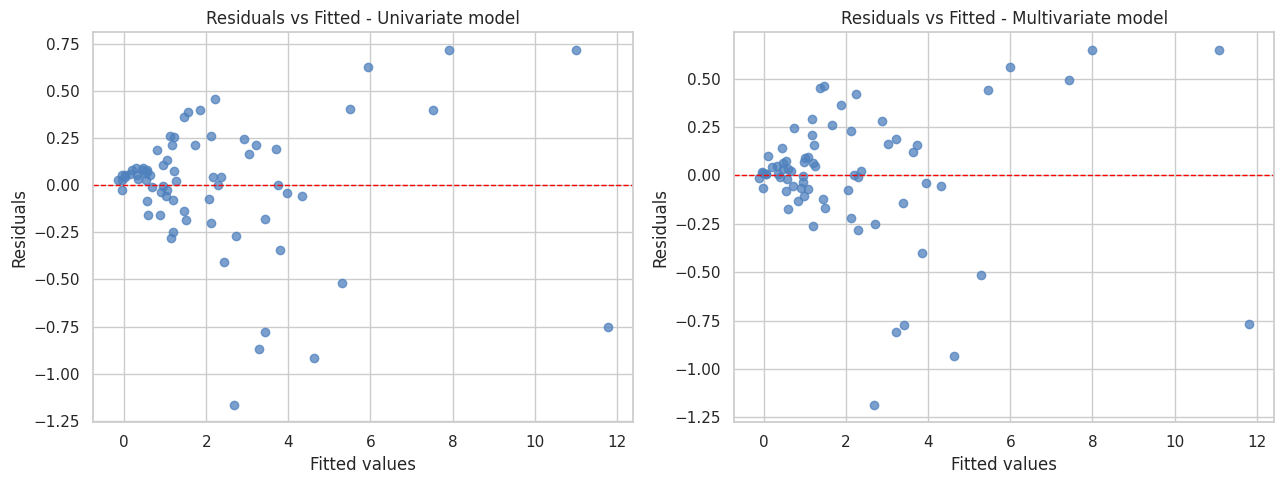

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fitted_col, resid_col, title in zip(
        axes,
        ["fitted_uni", "fitted_mul"],
        ["residual_uni", "residual_mul"],
        ["Univariate model", "Multivariate model"]):
    ax.scatter(data_diag[fitted_col], data_diag[resid_col],
               color="#4f81bd", alpha=0.75)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title(f"Residuals vs Fitted - {title}")

plt.tight_layout()
plt.show()

For both models the residuals are largely scattered around zero with no strong curved or systematic
pattern, suggesting the linearity assumption is reasonably satisfied across the bulk of the data. However,
there is a notable cluster of more negative residuals at the high fitted value end (corresponding to the
large rivers). This slight pattern reflects the right skew in the data rather than a fundamental
non-linearity in the relationship; the data from high-flow stations tends to show the model slightly
over-predicting. This is an important limitation to note.

### 6.2 Assumption 2 - Independence (Durbin-Watson test)

In [18]:
dw_uni = durbin_watson(model_uni.resid)
dw_mul = durbin_watson(model_mul.resid)
print(f"Durbin-Watson statistic (univariate):    {dw_uni:.4f}")
print(f"Durbin-Watson statistic (multivariate):  {dw_mul:.4f}")
print()
print("Reference: DW near 2 indicates no autocorrelation.")
print("           DW < 1.5 may indicate positive autocorrelation.")

Durbin-Watson statistic (univariate):    1.2871
Durbin-Watson statistic (multivariate):  1.3029

Reference: DW near 2 indicates no autocorrelation.
           DW < 1.5 may indicate positive autocorrelation.


The Durbin-Watson statistic is approximately **1.29** for both models. A value of 2 indicates no
autocorrelation; values below 1.5 suggest positive autocorrelation among residuals. The statistics here
are below the conventional lower bound of 1.5, indicating a degree of positive autocorrelation.

This is expected in hydrological data: the dataset consists of readings from different gauging stations
at different times, and stations on the same river system, or readings close in time, will tend to
produce similar residuals. The independence assumption is the most difficult to satisfy fully in
cross-sectional water level data and represents a genuine limitation of the OLS framework here.

### 6.3 Assumption 3 - Homoscedasticity (constant variance)

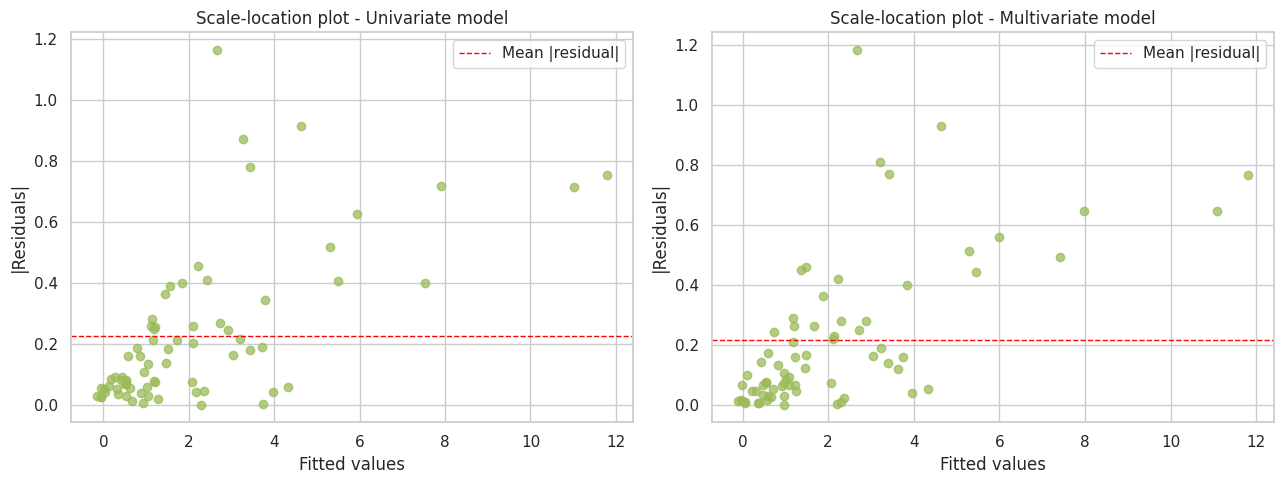

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fitted_col, resid_col, title in zip(
        axes,
        ["fitted_uni", "fitted_mul"],
        ["residual_uni", "residual_mul"],
        ["Univariate model", "Multivariate model"]):
    ax.scatter(data_diag[fitted_col], np.abs(data_diag[resid_col]),
               color="#9bbb59", alpha=0.75)
    ax.axhline(data_diag[resid_col].abs().mean(), color="red",
               linestyle="--", linewidth=1, label="Mean |residual|")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("|Residuals|")
    ax.set_title(f"Scale-location plot - {title}")
    ax.legend()

plt.tight_layout()
plt.show()

The scale-location plots reveal some spread variation: absolute residuals tend to be larger at
higher fitted values (larger river stations), indicating mild heteroscedasticity. The residual spread is
not constant across all levels of the fitted values. This means the standard errors reported in the OLS
summary may be slightly understated at the high end, though the effect is moderate and the overall
conclusions are not invalidated.

### 6.4 Assumption 4 - Normality of residuals (Q-Q plot and Shapiro-Wilk test)

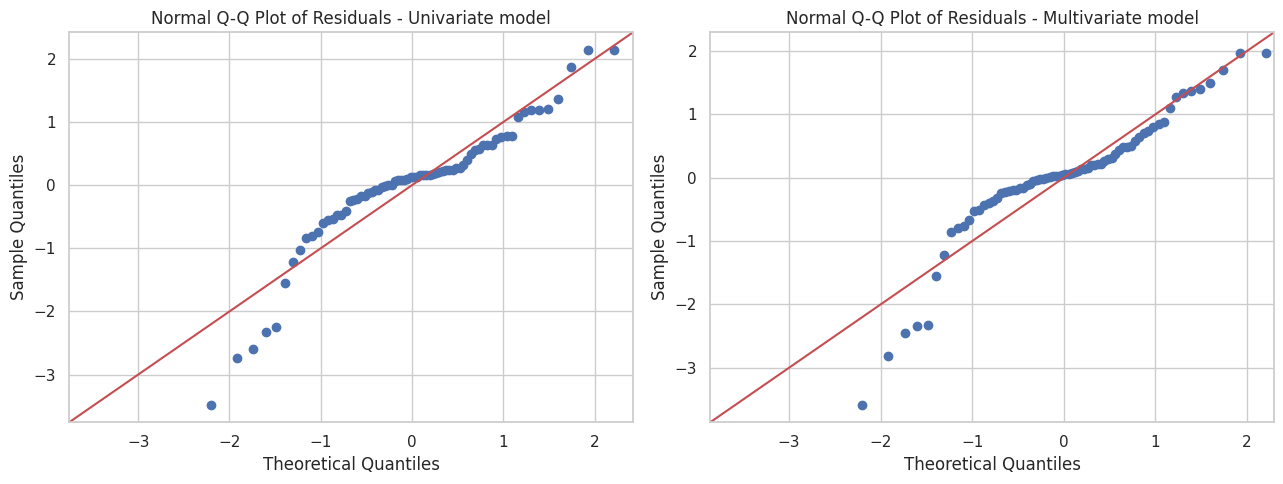

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, resid_col, title in zip(
        axes,
        ["residual_uni", "residual_mul"],
        ["Univariate model", "Multivariate model"]):
    sm.qqplot(data_diag[resid_col], line="45", fit=True, ax=ax)
    ax.set_title(f"Normal Q-Q Plot of Residuals - {title}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

plt.tight_layout()
plt.show()

In [21]:
# Shapiro-Wilk normality test
from scipy.stats import shapiro
stat_uni, p_uni = shapiro(model_uni.resid)
stat_mul, p_mul = shapiro(model_mul.resid)
print(f"Shapiro-Wilk test (univariate):   W = {stat_uni:.4f},  p-value = {p_uni:.6f}")
print(f"Shapiro-Wilk test (multivariate): W = {stat_mul:.4f},  p-value = {p_mul:.6f}")
print()
print("Null hypothesis: residuals are normally distributed.")
print("A p-value < 0.05 provides evidence against normality.")

Shapiro-Wilk test (univariate):   W = 0.9029,  p-value = 0.000040
Shapiro-Wilk test (multivariate): W = 0.8969,  p-value = 0.000023

Null hypothesis: residuals are normally distributed.
A p-value < 0.05 provides evidence against normality.


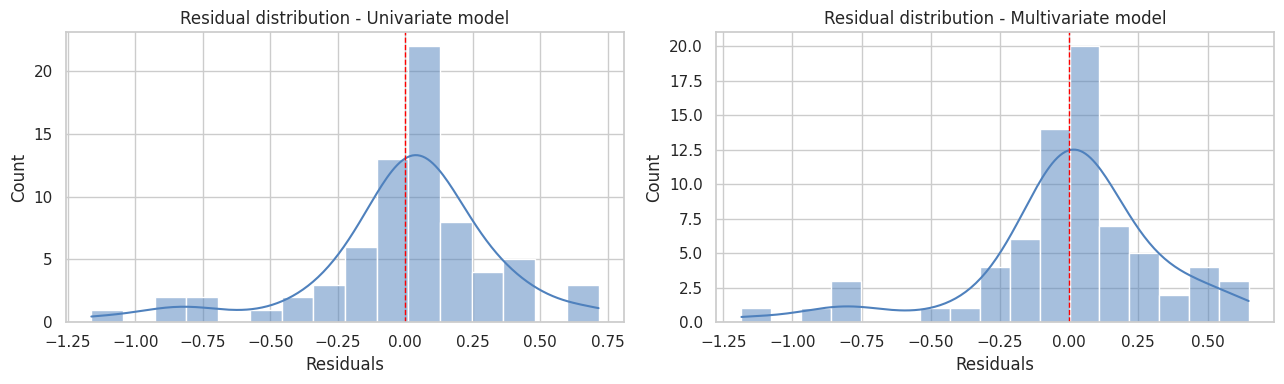

In [22]:
# Histogram of residuals
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, resid_col, title in zip(
        axes,
        ["residual_uni", "residual_mul"],
        ["Univariate model", "Multivariate model"]):
    sns.histplot(data_diag[resid_col], kde=True, ax=ax, color="#4f81bd")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Residual distribution - {title}")
    ax.set_xlabel("Residuals")

plt.tight_layout()
plt.show()

The normal Q-Q plots show that the residuals follow the 45-degree reference line reasonably well
in the middle of the distribution, but there are noticeable deviations at both tails - especially at the
lower tail - indicating heavier tails than a normal distribution. The residual histograms show a
left skew.

The Shapiro-Wilk test confirms this: both p-values are well below 0.05, providing strong evidence
against the normality assumption. The non-normality arises from the underlying right skew in the water
level data, which carries into the residuals. With a sample size of 72, the central limit theorem
provides some robustness to the t-statistics and p-values reported in the summary, but hypothesis tests
and confidence intervals should be interpreted cautiously in light of this departure.

### 6.5 Assumption 5 - No multicollinearity (VIF, multivariate model only)

In [23]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X_mul.columns
vif_data["VIF"] = [variance_inflation_factor(X_mul.values, i)
                   for i in range(X_mul.shape[1])]
print("Variance Inflation Factor (VIF):")
print(vif_data.to_string(index=False))
print()
print("VIF < 5: no problematic multicollinearity")
print("VIF 5-10: moderate concern")
print("VIF > 10: serious multicollinearity")

Variance Inflation Factor (VIF):
         Feature    VIF
           const 2.5109
Water_Level_Xt_1 1.1322
     24HrRF_Xt_1 1.1322

VIF < 5: no problematic multicollinearity
VIF 5-10: moderate concern
VIF > 10: serious multicollinearity


Both predictors have VIF values of approximately **1.13**, which is very close to 1 and well below
the conventional threshold of 5. This confirms that there is no problematic multicollinearity between
the current water level and the 24-hour rainfall. The two predictors bring independent information, and
the OLS coefficient estimates are therefore stable and interpretable. The high VIF for the intercept
constant is expected and should not be of concern.

### 6.6 Diagnostics using statsmodels plot_regress_exog (univariate)

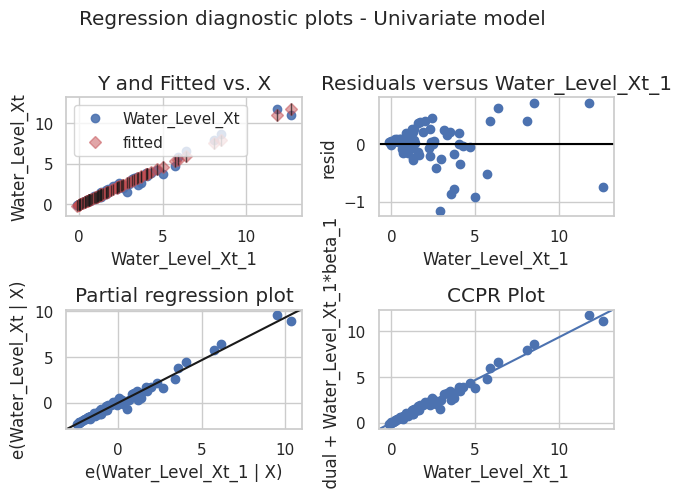

In [24]:
fig = sm.graphics.plot_regress_exog(model_uni, "Water_Level_Xt_1")
plt.suptitle("Regression diagnostic plots - Univariate model", y=1.02)
plt.tight_layout()
plt.show()

## 7. Model evaluation

Both models are evaluated on the training data using four standard metrics:

- **R-squared (R2):** proportion of variance in the target explained by the model.
- **Mean Squared Error (MSE):** average squared difference between actual and predicted values.
- **Root Mean Squared Error (RMSE):** square root of MSE, in the same units as the target (mm).
- **Mean Absolute Error (MAE):** average absolute difference, in mm.

In [25]:
metrics = {}
for name, m in [("Univariate", model_uni), ("Multivariate", model_mul)]:
    pred = m.fittedvalues
    r2   = r2_score(y, pred)
    mse  = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y, pred)
    metrics[name] = {"R-squared": r2, "MSE": mse, "RMSE": rmse, "MAE": mae}

metrics_df = pd.DataFrame(metrics).T
print("Model Evaluation Metrics:")
print(metrics_df.to_string())

Model Evaluation Metrics:
              R-squared    MSE   RMSE    MAE
Univariate       0.9799 0.1121 0.3348 0.2240
Multivariate     0.9804 0.1093 0.3306 0.2171


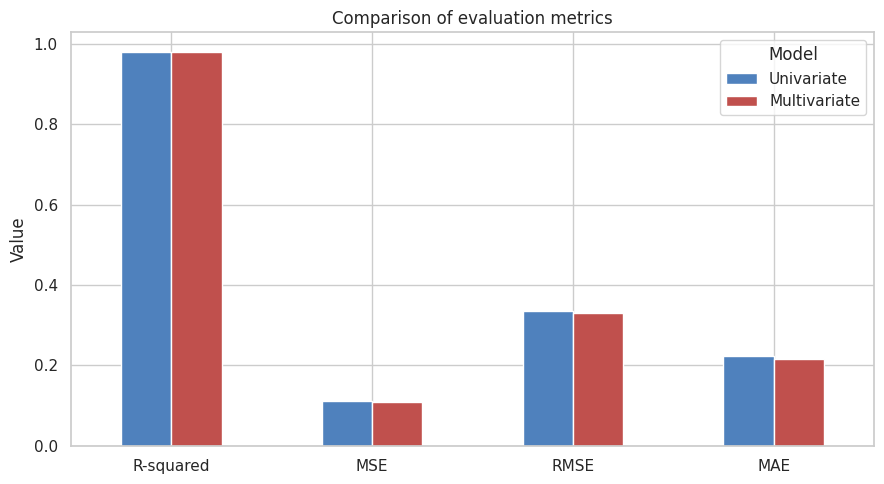

In [26]:
metrics_df.T.plot(kind="bar", figsize=(9, 5), color=["#4f81bd", "#c0504d"])
plt.title("Comparison of evaluation metrics")
plt.xticks(rotation=0)
plt.ylabel("Value")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

The evaluation results:

| Metric | Univariate | Multivariate |
|---|---|---|
| R-squared | 0.9799 | 0.9804 |
| MSE | 0.1121 | 0.1093 |
| RMSE | 0.3348 mm | 0.3306 mm |
| MAE | 0.2240 mm | 0.2171 mm |

The differences between the two models are negligible. The multivariate model reduces RMSE by only
0.004 mm and MAE by 0.007 mm over the univariate model - improvements that are practically
meaningless. The simpler univariate model achieves the same predictive performance, and the AIC
and BIC from the model summaries both prefer it.

**Selected final model: Univariate (current water level only)**

The fitted equation is:

$$\boxed{\widehat{\text{Water Level}_{t+12h}} = -0.0467 + 0.9344 \times \text{Water Level}_{t}}$$

An RMSE of approximately 0.33 mm is very small relative to the typical water levels observed (mean
2.1 mm, range -3.3 to 12.7 mm), indicating the model is practically highly accurate.

### 7.1 Predicted vs actual values plot (final model)

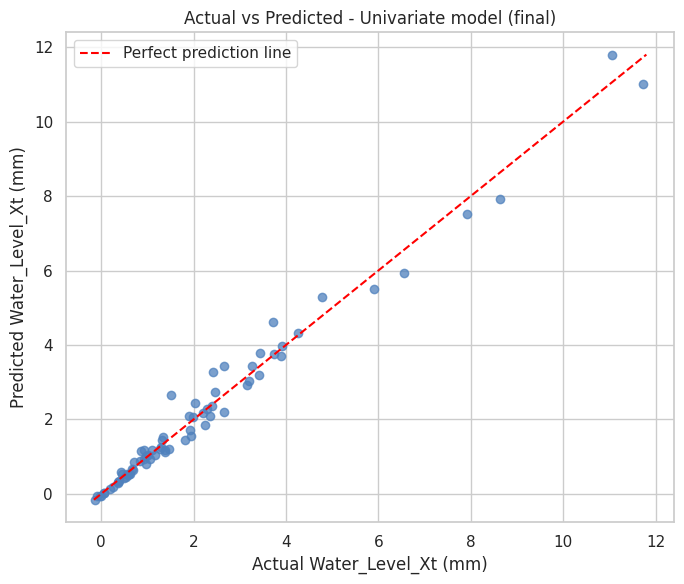

In [27]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y, model_uni.fittedvalues, color="#4f81bd", alpha=0.75)
min_val = min(y.min(), model_uni.fittedvalues.min())
max_val = max(y.max(), model_uni.fittedvalues.max())
ax.plot([min_val, max_val], [min_val, max_val], color="red",
        linestyle="--", linewidth=1.5, label="Perfect prediction line")
ax.set_xlabel("Actual Water_Level_Xt (mm)")
ax.set_ylabel("Predicted Water_Level_Xt (mm)")
ax.set_title("Actual vs Predicted - Univariate model (final)")
ax.legend()
plt.tight_layout()
plt.show()

Points lying on the red 45-degree line represent perfect predictions. The plot shows very tight
alignment between actual and predicted values across the full range, confirming the model's high
predictive accuracy. There are a few points that deviate slightly at the high end, corresponding to the
large river stations; these match the mild heteroscedasticity observed in the diagnostics.

### 7.2 Actual vs predicted water levels by observation

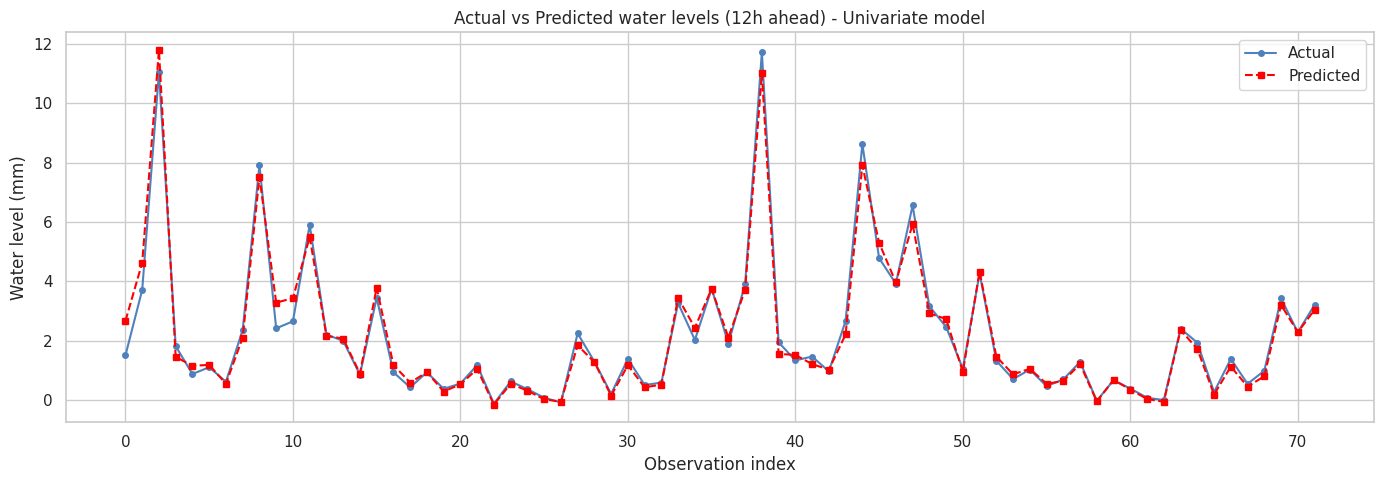

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))
x_idx = np.arange(len(y))
ax.plot(x_idx, y.values, "o-", color="#4f81bd", label="Actual", markersize=4)
ax.plot(x_idx, model_uni.fittedvalues.values, "s--", color="red",
        label="Predicted", markersize=4)
ax.set_xlabel("Observation index")
ax.set_ylabel("Water level (mm)")
ax.set_title("Actual vs Predicted water levels (12h ahead) - Univariate model")
ax.legend()
plt.tight_layout()
plt.show()

The actual and predicted series track each other extremely closely across all observations,
providing a visual confirmation of the high model accuracy. The predicted line closely follows every
peak and trough in the actual water levels.

## 8. Practical usefulness of the model for river water level forecasting

The univariate regression model produces 12-hour ahead water level forecasts with an R-squared of
0.98 and an RMSE of approximately 0.33 mm. In the context of flood early warning and river management,
several aspects make this operationally valuable:

**Early warning lead time.** A reliable 12-hour forecast gives water management authorities, emergency
services, and downstream communities sufficient time to issue warnings, mobilise resources, evacuate
low-lying areas, or operate flood gates and irrigation structures. In Sri Lanka's major river systems
(Mahaweli, Kelani, Kalu), a 12-hour warning window is considered operationally significant.

**Simplicity and robustness.** The model requires only one real-time input, the current water level at
the gauging station, which is routinely telemetered. There is no dependency on rainfall forecasts, which
carry their own uncertainty. A model with a single telemetered input is easy to deploy, fails less often
due to missing inputs, and is straightforward to audit.

**High accuracy.** An RMSE of 0.33 mm is small relative to the observed range of water levels
(-3.3 to 12.7 mm). In flood management, the difference between an alert threshold and the current level
may be a fraction of a metre, so sub-millimetre prediction accuracy is practically meaningful.

**Interpretability.** The model has a clear physical interpretation: the river level 12 hours later
is approximately 0.93 times the current level plus a small constant. This mirrors the physical
persistence of river flow over a 12-hour horizon and can be readily explained to non-technical
stakeholders.

## 9. Strengths and limitations of the model

### Strengths

- **Extremely high predictive power:** the current water level alone explains 98% of the variance in
  the level 12 hours ahead. This reflects the physical persistence of river systems over short time
  horizons.
- **Parsimonious:** a single predictor, interpretable coefficient, and no tuning parameters. The model
  cannot over-fit in the way complex machine learning models can.
- **Low input data requirement:** only the current water level is needed at forecast time. This is
  already collected continuously at every gauging station.
- **Statistically sound:** no multicollinearity; the model is overall significant (F-statistic
  p < 0.0001); the coefficient is significant and stable.

### Limitations

- **Independence assumption is imperfect:** the Durbin-Watson statistic of approximately 1.29 indicates
  positive autocorrelation among residuals. This is expected in hydrological cross-sectional data but
  means the OLS standard errors may be slightly under-estimated, and significance tests should be
  treated with some caution.
- **Non-normality of residuals:** the Shapiro-Wilk test rejects normality for both models (p < 0.001).
  This is driven by the right skew in water levels and affects the validity of confidence intervals for
  individual predictions.
- **Mild heteroscedasticity:** residual spread increases at higher water levels. The model is slightly
  less precise for large river stations than for smaller ones.
- **Small sample size:** with only 72 training observations from 72 different stations, the model is
  fit on a cross-sectional snapshot rather than a proper time series. No temporal dynamics (lagged
  effects beyond one step, seasonality, or long-term trends) are captured.
- **Rainfall not useful:** the 24-hour rainfall predictor is statistically insignificant once the
  current level is included. While rainfall undoubtedly drives floods, its effect on the 12-hour ahead
  level may already be embedded in the current level itself, or it may manifest over different time
  scales. A model with longer rainfall lags or a different temporal aggregation could be more informative.
- **No out-of-sample validation:** both models were evaluated on the same 72 rows used for fitting.
  True generalisation performance can only be assessed when the test dataset is applied. The very high
  training R-squared may not fully transfer to new stations or different seasons.
- **Linear assumption:** the model assumes a linear relationship between the current and future water
  levels. During extreme flood events, river dynamics become non-linear (bank overflow, backwater
  effects), and the model may under-perform outside the range seen in training.

---

## Summary

| Item | Result |
|---|---|
| Training rows | 72 (after removing 6 with missing target) |
| Final model | Univariate OLS: Water_Level_Xt = -0.047 + 0.934 * Water_Level_Xt_1 |
| R-squared | 0.980 |
| Adjusted R-squared | 0.980 |
| RMSE | 0.335 mm |
| MAE | 0.224 mm |
| Rainfall predictor | Not significant (p = 0.187); excluded from final model |
| VIF | 1.13 (no multicollinearity concern) |
| Normality | Violated (Shapiro-Wilk p < 0.001) |
| Independence | Mild positive autocorrelation (DW = 1.29) |
| Homoscedasticity | Mild heteroscedasticity at high water levels |

**The final model is simple, accurate, and physically interpretable. Its primary limitation is the
non-normality and mild autocorrelation of residuals, which are inherent properties of hydrological
cross-sectional data rather than modelling failures. These should be acknowledged when reporting
confidence intervals or conducting significance tests.**
